# Basic ML for Security Data

In [1]:
# import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## 1. Data Exploration

In [3]:
# Định nghĩa cột
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Tải dữ liệu lên
train_df = pd.read_csv('KDDTrain+.txt', header=None, names=columns)
test_df = pd.read_csv('KDDTest+.txt', header=None, names=columns)

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (125973, 43)
Test set shape: (22544, 43)


### a. Khảo sát phân phối các nhãn attack
Liệt kê chi tiết xem trong tập dữ liệu có bao nhiêu loại tấn công (các nhãn chi tiết trong cột `label`) và gom nhóm chúng thành 5 nhóm tấn công chính (Normal, DoS, Probe, R2L, U2R).

In [4]:
# 1. Liệt kê các loại tấn công chi tiết có trong tập Train (ngoại trừ 'normal')
specific_attacks_train = train_df[train_df['label'] != 'normal']['label'].unique()
print(f"Số lượng loại tấn công chi tiết trong tập Train: {len(specific_attacks_train)}")
print("Các loại tấn công chi tiết trong tập Train:")
print(specific_attacks_train)

Số lượng loại tấn công chi tiết trong tập Train: 22
Các loại tấn công chi tiết trong tập Train:
['neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap' 'satan'
 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop' 'rootkit'
 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land' 'loadmodule' 'spy'
 'perl']


In [5]:
# 2. Định nghĩa từ điển map từ nhãn chi tiết sang 5 nhóm chính
attack_map = {
    'normal': 'Normal',
    
    # DoS (Denial of Service)
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS',
    'teardrop': 'DoS', 'mailbomb': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'apache2': 'DoS', 'worm': 'DoS',
    
    # Probe (Scanning/Surveillance)
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L (Remote to Local)
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'sendmail': 'R2L', 'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    
    # U2R (User to Root privilege escalation)
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
}

# Áp dụng mapping vào dataframe để tạo cột 'attack_category'
train_df['attack_category'] = train_df['label'].map(attack_map)
test_df['attack_category'] = test_df['label'].map(attack_map)

In [6]:
# 3. In ra số lượng và tỷ lệ phần trăm của từng nhóm tấn công chính
print("\nPhân phối các nhóm tấn công chính trong tập Train:")
train_counts = train_df['attack_category'].value_counts()
train_pct = train_df['attack_category'].value_counts(normalize=True) * 100
for cat in train_counts.index:
    print(f"  {cat:<8}: {train_counts[cat]:>6} mẫu ({train_pct[cat]:.2f}%)")


Phân phối các nhóm tấn công chính trong tập Train:
  Normal  :  67343 mẫu (53.46%)
  DoS     :  45927 mẫu (36.46%)
  Probe   :  11656 mẫu (9.25%)
  R2L     :    995 mẫu (0.79%)
  U2R     :     52 mẫu (0.04%)


### b. Khảo sát các categorical features (đặc trưng phân loại)
Thống kê số lượng unique vales của các đặc trưng phân loại (`protocol_type`, `service`, `flag`).

In [7]:
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    print(f"Số lượng giá trị unique của cột '{col}': {train_df[col].nunique()}")

Số lượng giá trị unique của cột 'protocol_type': 3
Số lượng giá trị unique của cột 'service': 70
Số lượng giá trị unique của cột 'flag': 11


### c. Xem xét thống kê các đặc trưng dạng số (Numeric Feature Statistics)

Thống kê mô tả (min, mean, max) của đặc trưng `src_bytes` và `dst_bytes`.

In [8]:
print(train_df[['src_bytes', 'dst_bytes']].describe().to_string())

          src_bytes     dst_bytes
count  1.259730e+05  1.259730e+05
mean   4.556674e+04  1.977911e+04
std    5.870331e+06  4.021269e+06
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    4.400000e+01  0.000000e+00
75%    2.760000e+02  5.160000e+02
max    1.379964e+09  1.309937e+09


## 2. Data Preprocessing
Mã hóa nhãn nhị phân, nhãn đa lớp, thực hiện One-hot encoding cho các biến phân loại, phân chia tập dữ liệu thành Train/Test và chuẩn hóa thang đo bằng StandardScaler.

### a. Mã hóa One-hot encoding bằng `pd.get_dummies()`

Thực hiện mã hóa One-hot cho 3 đặc trưng phân loại (`protocol_type`, `service`, `flag`) và kiểm tra số lượng đặc trưng mới sau khi mã hóa.

In [9]:
# Tạo nhãn nhị phân (Normal = 0, Attack = 1)
y_binary = np.where(train_df['label'] == 'normal', 0, 1)

# Tạo nhãn đa lớp (Normal=0, DoS=1, Probe=2, R2L=3, U2R=4)
multiclass_label_map = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}
y_multiclass = train_df['attack_category'].map(multiclass_label_map)

# Loại bỏ cột label gốc và difficulty_level để thu được ma trận đặc trưng X
X = train_df.drop(columns=['label', 'difficulty_level', 'attack_category'])

# Thực hiện One-hot encoding cho các đặc trưng phân loại
categorical_cols = ['protocol_type', 'service', 'flag']
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print(f"Kích thước ma trận đặc trưng X trước One-hot encoding: {X.shape}")
print(f"Kích thước ma trận đặc trưng X sau One-hot encoding: {X_encoded.shape}")

Kích thước ma trận đặc trưng X trước One-hot encoding: (125973, 41)
Kích thước ma trận đặc trưng X sau One-hot encoding: (125973, 122)


### b. Chia tập Train/Test theo tỉ lệ 80/20 với `stratify=y_binary`

Sử dụng hàm `train_test_split` để chia dữ liệu và in ra số lượng dòng của mỗi tập.

In [10]:
# Phân chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X_encoded, y_binary, y_multiclass, test_size=0.2, stratify=y_binary, random_state=42
)

print(f"Số lượng bản ghi trong tập Training: {X_train.shape[0]}")
print(f"Số lượng bản ghi trong tập Test: {X_test.shape[0]}")

Số lượng bản ghi trong tập Training: 100778
Số lượng bản ghi trong tập Test: 25195


### c. Áp dụng chuẩn hóa thang đo đặc trưng với `StandardScaler`

Sử dụng `StandardScaler` để đưa các đặc trưng về phân phối chuẩn (mean=0, std=1) phục vụ mô hình Logistic Regression.

In [11]:
# Khởi tạo StandardScaler và thực hiện chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Binary Classification (Normal vs Attack)
Huấn luyện ba mô hình phân loại nhị phân bao gồm **Logistic Regression**, **Decision Tree (max_depth=10)**, và **Random Forest (100 trees, max_depth=15)**. Với mỗi mô hình, thực hiện 5-fold cross-validation trên tập Train và đánh giá hiệu năng chi tiết trên tập Test.


=== Huấn luyện mô hình: Logistic Regression ===
Đang tính toán 5-fold Cross-Validation...
  CV Accuracy trung bình: 0.9740
  Test Accuracy: 0.9723
  Precision    : 0.9766
  Recall       : 0.9637
  F1-Score     : 0.9701
  Ma trận nhầm lẫn (Confusion Matrix):
[[13198   271]
 [  426 11300]]

=== Huấn luyện mô hình: Decision Tree ===
Đang tính toán 5-fold Cross-Validation...
  CV Accuracy trung bình: 0.9966
  Test Accuracy: 0.9976
  Precision    : 0.9975
  Recall       : 0.9973
  F1-Score     : 0.9974
  Ma trận nhầm lẫn (Confusion Matrix):
[[13440    29]
 [   32 11694]]

=== Huấn luyện mô hình: Random Forest ===
Đang tính toán 5-fold Cross-Validation...
  CV Accuracy trung bình: 0.9981
  Test Accuracy: 0.9986
  Precision    : 0.9995
  Recall       : 0.9974
  F1-Score     : 0.9985
  Ma trận nhầm lẫn (Confusion Matrix):
[[13463     6]
 [   30 11696]]

Đã lưu biểu đồ ma trận nhầm lẫn vào file 'fig1_binary_confusion_matrices.png' thành công!


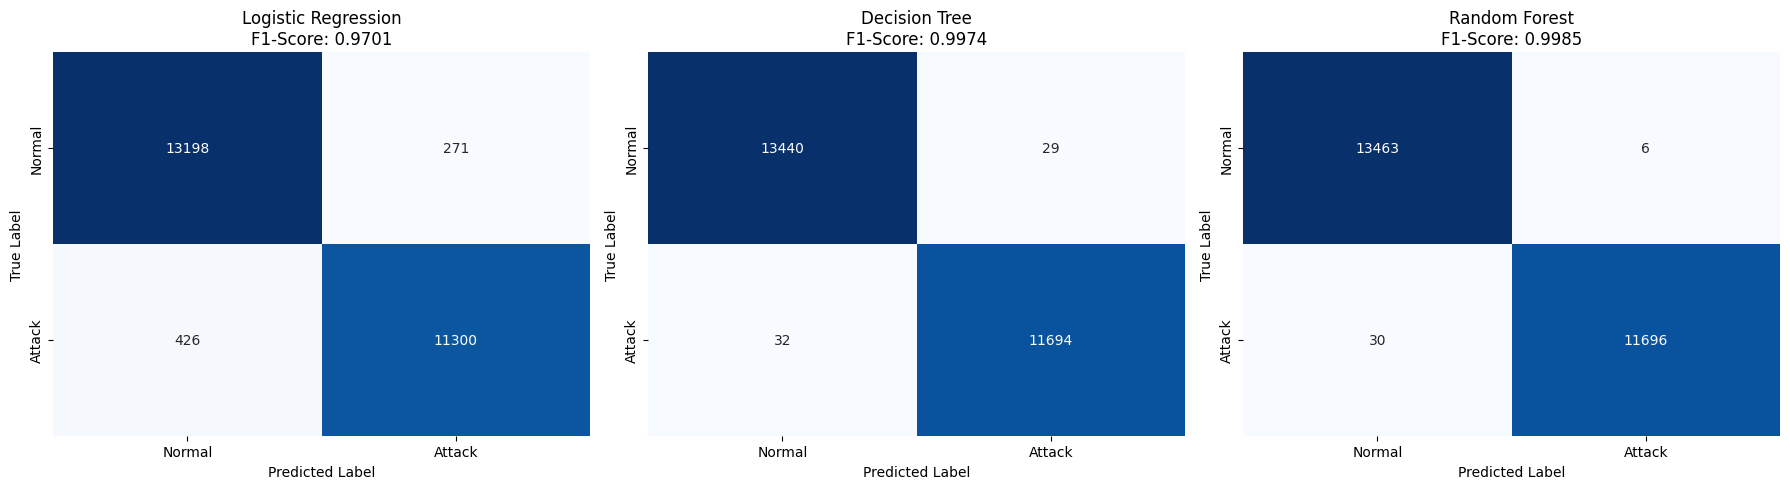

In [12]:
# Định nghĩa các mô hình
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(max_depth=10, random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42), False)
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (model, use_scaling)) in enumerate(models.items()):
    print(f"\n=== Huấn luyện mô hình: {name} ===")
    # Chọn dữ liệu đã chuẩn hóa cho Logistic Regression, dữ liệu gốc cho cây quyết định
    X_tr = X_train_scaled if use_scaling else X_train
    X_te = X_test_scaled if use_scaling else X_test
    
    # Chạy 5-fold cross-validation trên tập Train
    print("Đang tính toán 5-fold Cross-Validation...")
    cv_scores = cross_val_score(model, X_tr, y_train_bin, cv=5, scoring='accuracy', n_jobs=-1)
    cv_mean = cv_scores.mean()
    print(f"  CV Accuracy trung bình: {cv_mean:.4f}")
    
    # Huấn luyện mô hình trên toàn bộ tập Train
    model.fit(X_tr, y_train_bin)
    
    # Dự đoán trên tập Test
    y_pred = model.predict(X_te)
    
    # Tính toán các chỉ số đánh giá
    test_acc = accuracy_score(y_test_bin, y_pred)
    precision = precision_score(y_test_bin, y_pred)
    recall = recall_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred)
    cm = confusion_matrix(y_test_bin, y_pred)
    
    results[name] = {
        'CV Accuracy': cv_mean,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Confusion Matrix': cm
    }
    
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print("  Ma trận nhầm lẫn (Confusion Matrix):")
    print(cm)
    
    # Vẽ và lưu biểu đồ ma trận nhầm lẫn của mỗi mô hình
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    axes[idx].set_title(f"{name}\nF1-Score: {f1:.4f}")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('fig1_binary_confusion_matrices.png', dpi=300)
print("\nĐã lưu biểu đồ ma trận nhầm lẫn vào file 'fig1_binary_confusion_matrices.png' thành công!")

## 4. Multi-class Classification (5 Attack Categories)

Huấn luyện 3 mô hình cho bài toán phân loại đa lớp (5 lớp bao gồm: Normal, DoS, Probe, R2L, U2R). Với mỗi mô hình, thực hiện huấn luyện trên toàn bộ tập Train và kiểm thử hiệu năng chi tiết trên tập Test.


=== Huấn luyện mô hình đa lớp: Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
         DoS       1.00      1.00      1.00      9105
       Probe       0.98      0.96      0.97      2389
         R2L       0.77      0.79      0.78       226
         U2R       0.38      0.50      0.43         6

    accuracy                           0.99     25195
   macro avg       0.82      0.85      0.83     25195
weighted avg       0.99      0.99      0.99     25195

Ma trận nhầm lẫn (Confusion Matrix):
[[13342    27    48    48     4]
 [   13  9091     1     0     0]
 [   87    12  2288     2     0]
 [   43     1     3   178     1]
 [    0     0     0     3     3]]

=== Huấn luyện mô hình đa lớp: Decision Tree ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9105
       Probe       1.00      0.99      

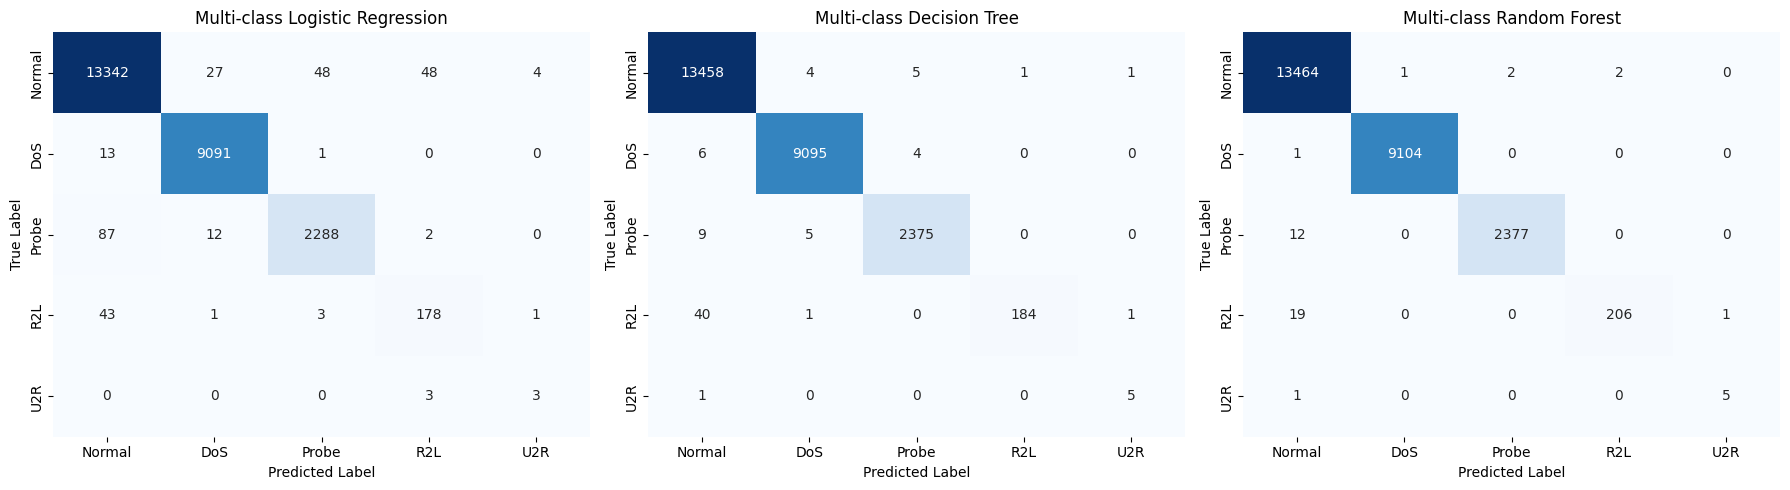

In [13]:
# Định nghĩa danh sách các nhóm nhãn đa lớp
class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
results_multi = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, (model, use_scaling)) in enumerate(models.items()):
    print(f"\n=== Huấn luyện mô hình đa lớp: {name} ===")
    X_tr = X_train_scaled if use_scaling else X_train
    X_te = X_test_scaled if use_scaling else X_test
    
    # Huấn luyện mô hình với nhãn đa lớp (y_train_multi)
    model.fit(X_tr, y_train_multi)
    
    # Dự đoán
    y_pred = model.predict(X_te)
    
    # In báo cáo đánh giá chi tiết
    print(classification_report(y_test_multi, y_pred, target_names=class_names))
    
    # Tính toán ma trận nhầm lẫn
    cm = confusion_matrix(y_test_multi, y_pred)
    print("Ma trận nhầm lẫn (Confusion Matrix):")
    print(cm)
    
    results_multi[name] = {
        'Confusion Matrix': cm
    }
    
    # Vẽ và lưu biểu đồ ma trận nhầm lẫn đa lớp
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(f"Multi-class {name}")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('fig2_multiclass_confusion_matrices.png', dpi=300)
print("\nĐã lưu biểu đồ ma trận nhầm lẫn đa lớp vào file 'fig2_multiclass_confusion_matrices.png' thành công!")

## 5. So sánh mô hình (Model Comparison)
So sánh tổng quan cả 3 mô hình ở binary và multi classification dựa trên Accuracy, Precision, Recall, F1-Score.

=== BẢNG SO SÁNH PHÂN LOẠI NHỊ PHÂN (BINARY CLASSIFICATION) ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9723     0.9766  0.9637    0.9701
Decision Tree          0.9976     0.9975  0.9973    0.9974
Random Forest          0.9986     0.9995  0.9974    0.9985

=== BẢNG SO SÁNH PHÂN LOẠI ĐA LỚP (MULTICLASS CLASSIFICATION - MACRO AVERAGE) ===
                     Macro Accuracy  Macro Precision  Macro Recall  Macro F1-Score
Logistic Regression          0.9884           0.8217        0.8469          0.8324
Decision Tree                0.9969           0.9400        0.9279          0.9312
Random Forest                0.9985           0.9641        0.9479          0.9556

=> Mô hình nhị phân tốt nhất (F1-Score): Random Forest (0.9985)
=> Mô hình đa lớp tốt nhất (Macro F1-Score): Random Forest (0.9556)

Đã lưu biểu đồ so sánh 3 bảng biểu vào file 'fig3_model_comparison.png' thành công!


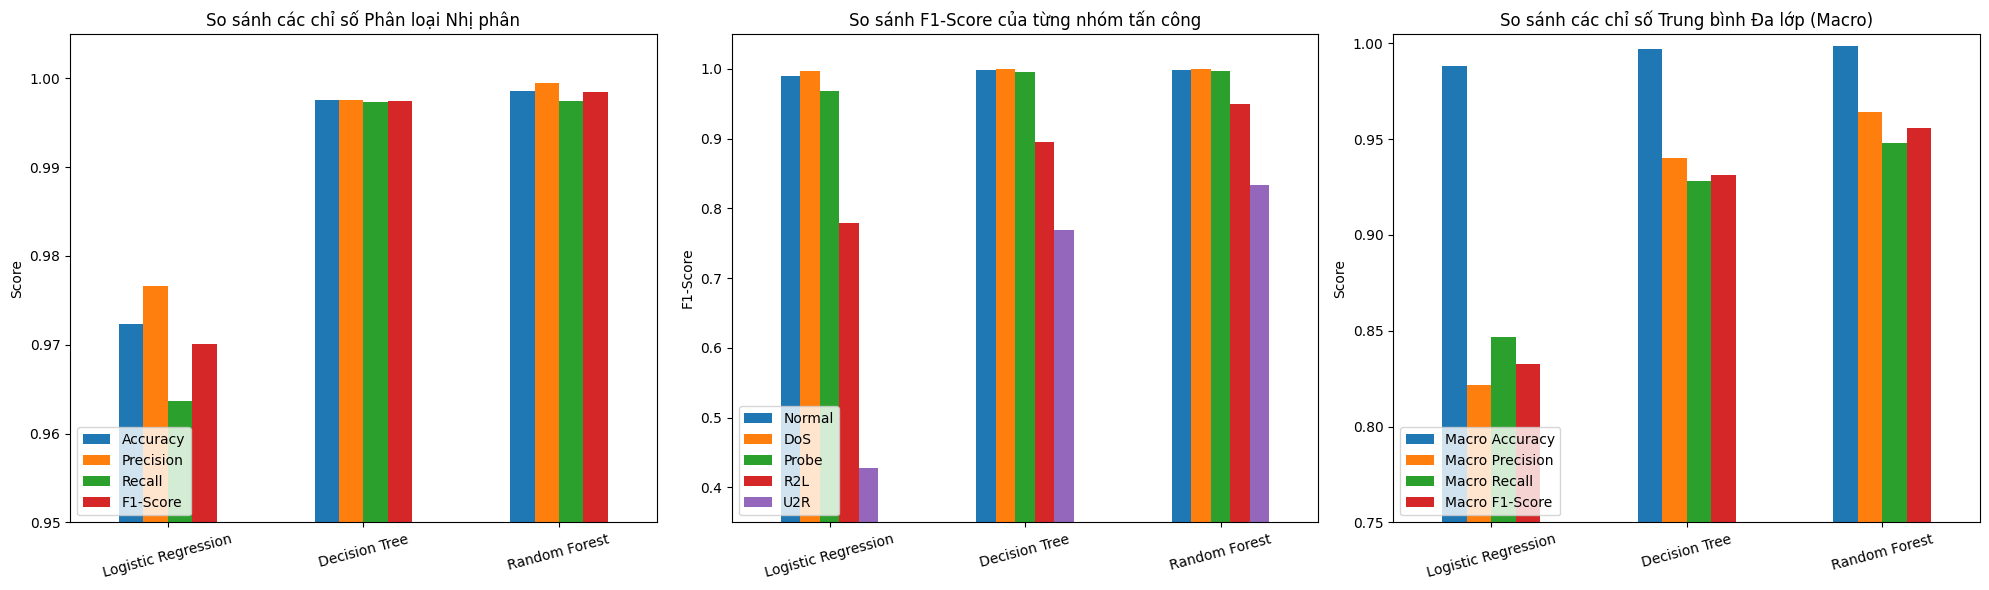

In [14]:
# Khởi tạo các từ điển lưu trữ kết quả để vẽ đồ thị
binary_metrics = {}
multiclass_f1_scores = {}
multiclass_macro_metrics = {}

# Thu thập chỉ số nhị phân
for name, (model, use_scaling) in models.items():
    X_tr = X_train_scaled if use_scaling else X_train
    X_te = X_test_scaled if use_scaling else X_test
    
    # Chạy lại nhị phân để lấy kết quả chính xác
    model.fit(X_tr, y_train_bin)
    y_pred = model.predict(X_te)
    
    binary_metrics[name] = {
        'Accuracy': accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall': recall_score(y_test_bin, y_pred),
        'F1-Score': f1_score(y_test_bin, y_pred)
    }

# Thu thập chỉ số đa lớp
for name, (model, use_scaling) in models.items():
    X_tr = X_train_scaled if use_scaling else X_train
    X_te = X_test_scaled if use_scaling else X_test
    
    model.fit(X_tr, y_train_multi)
    y_pred = model.predict(X_te)
    
    report = classification_report(y_test_multi, y_pred, target_names=class_names, output_dict=True)
    
    multiclass_f1_scores[name] = {cls: report[cls]['f1-score'] for cls in class_names}
    multiclass_macro_metrics[name] = {
        'Macro Accuracy': report['accuracy'],
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1-Score': report['macro avg']['f1-score']
    }

# Convert to DataFrames and print side-by-side comparison tables
df_bin = pd.DataFrame(binary_metrics).T
df_multi = pd.DataFrame(multiclass_macro_metrics).T
df_multi_f1 = pd.DataFrame(multiclass_f1_scores).T
df_multi_macro = df_multi

print("=== BẢNG SO SÁNH PHÂN LOẠI NHỊ PHÂN (BINARY CLASSIFICATION) ===")
print(df_bin.round(4).to_string())

print("\n=== BẢNG SO SÁNH PHÂN LOẠI ĐA LỚP (MULTICLASS CLASSIFICATION - MACRO AVERAGE) ===")
print(df_multi.round(4).to_string())

# Identify best models
best_bin_model = df_bin['F1-Score'].idxmax()
best_bin_f1 = df_bin.loc[best_bin_model, 'F1-Score']

best_multi_model = df_multi['Macro F1-Score'].idxmax()
best_multi_f1 = df_multi.loc[best_multi_model, 'Macro F1-Score']

print(f"\n=> Mô hình nhị phân tốt nhất (F1-Score): {best_bin_model} ({best_bin_f1:.4f})")
print(f"=> Mô hình đa lớp tốt nhất (Macro F1-Score): {best_multi_model} ({best_multi_f1:.4f})")

# Vẽ đồ thị so sánh 3 bảng biểu (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1 (Trái): So sánh các chỉ số Phân loại Nhị phân
df_bin.plot(kind='bar', ax=axes[0])
axes[0].set_title('So sánh các chỉ số Phân loại Nhị phân')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.95, 1.005) # Thu nhỏ khoảng cách để nhìn rõ sự chênh lệch
axes[0].legend(loc='lower left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# Panel 2 (Giữa): So sánh F1-Score từng nhóm tấn công (Đa lớp)
df_multi_f1.plot(kind='bar', ax=axes[1])
axes[1].set_title('So sánh F1-Score của từng nhóm tấn công')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.35, 1.05)
axes[1].legend(loc='lower left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Panel 3 (Phải): So sánh chỉ số trung bình Đa lớp (Macro)
df_multi_macro.plot(kind='bar', ax=axes[2])
axes[2].set_title('So sánh các chỉ số Trung bình Đa lớp (Macro)')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0.75, 1.005)
axes[2].legend(loc='lower left')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('fig3_model_comparison.png', dpi=300)
print("\nĐã lưu biểu đồ so sánh 3 bảng biểu vào file 'fig3_model_comparison.png' thành công!")

## 6. Phân tích bảo mật chuyên sâu (Security-Focused Analysis)
Phân tích FN, FP rate, các nhóm tấn công khó phát hiện nhất và xếp hạng các features quan trọng nhất được sử dụng trong Random Forest binary.

=== PHÂN TÍCH CHỈ SỐ BẢO MẬT (RANDOM FOREST NHỊ PHÂN) ===
Tỷ lệ bỏ sót cuộc tấn công (Missed Attack / FN Rate): 0.2558%
Tỷ lệ cảnh báo giả (False Alarm / FP Rate): 0.0445%

=== TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT (RANDOM FOREST) ===
                    Feature  Importance
                  src_bytes    0.149149
                  dst_bytes    0.090750
                    flag_SF    0.083784
                  logged_in    0.061350
     dst_host_same_srv_rate    0.055464
         dst_host_srv_count    0.055268
              same_srv_rate    0.049458
              diff_srv_rate    0.041325
   dst_host_srv_serror_rate    0.039836
     dst_host_diff_srv_rate    0.033855
                      count    0.025499
dst_host_same_src_port_rate    0.025074
dst_host_srv_diff_host_rate    0.022293
         protocol_type_icmp    0.020199
                    flag_S0    0.020012


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24440\2930881251.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')



Đã lưu biểu đồ đặc trưng quan trọng vào file 'fig4_feature_importance.png' thành công!


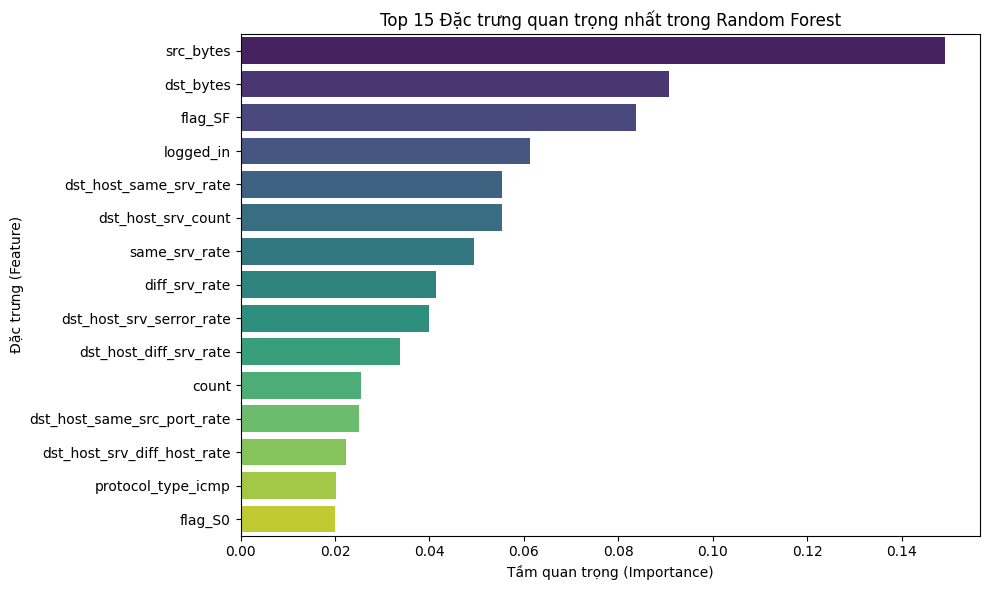

In [15]:
# Khởi tạo và huấn luyện Random Forest cho phân loại nhị phân để có kết quả chính xác
rf_binary = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_binary.fit(X_train, y_train_bin)
y_pred_rf = rf_binary.predict(X_test)

# Tính toán tỷ lệ bỏ sót (Missed Attack Rate - FN Rate) và tỷ lệ cảnh báo giả (False Alarm Rate - FP Rate)
cm_rf = confusion_matrix(y_test_bin, y_pred_rf)
TN, FP, FN, TP = cm_rf.ravel()

missed_attack_rate = FN / (FN + TP)
false_alarm_rate = FP / (FP + TN)

print("=== PHÂN TÍCH CHỈ SỐ BẢO MẬT (RANDOM FOREST NHỊ PHÂN) ===")
print(f"Tỷ lệ bỏ sót cuộc tấn công (Missed Attack / FN Rate): {missed_attack_rate:.4%}")
print(f"Tỷ lệ cảnh báo giả (False Alarm / FP Rate): {false_alarm_rate:.4%}")

# Trực quan hóa đặc trưng quan trọng (Feature Importance) của Random Forest
importances = rf_binary.feature_importances_
feature_names = X_encoded.columns
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(15)

print("\n=== TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT (RANDOM FOREST) ===")
print(df_importance.to_string(index=False))

# Vẽ đồ thị Top 15 đặc trưng quan trọng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Top 15 Đặc trưng quan trọng nhất trong Random Forest')
plt.xlabel('Tầm quan trọng (Importance)')
plt.ylabel('Đặc trưng (Feature)')
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=300)
print("\nĐã lưu biểu đồ đặc trưng quan trọng vào file 'fig4_feature_importance.png' thành công!")

## EXTENDED EXERCISES

## 1. Hyperparameter Tuning

Thay đổi `max_depth` đến hiệu năng của mô hình Decision Tree binary để xác định ngưỡng overfitting threshold.

In [16]:
# Khảo sát các giá trị max_depth
depths = [5, 10, 15, 20, None]
cv_scores_list = []
test_scores_list = []

for d in depths:
    dt_model = DecisionTreeClassifier(max_depth=d, random_state=42)
    
    # Tính 5-fold CV Accuracy trên tập Train
    cv_scores = cross_val_score(dt_model, X_train, y_train_bin, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores_list.append(cv_scores.mean())
    
    # Huấn luyện trên toàn bộ tập Train và tính Accuracy trên tập Test
    dt_model.fit(X_train, y_train_bin)
    y_pred = dt_model.predict(X_test)
    test_scores_list.append(accuracy_score(y_test_bin, y_pred))

# In bảng kết quả
df_tuning = pd.DataFrame({
    'max_depth': [str(d) for d in depths],
    'CV Accuracy': cv_scores_list,
    'Test Accuracy': test_scores_list
})
print("=== KẾT QUẢ TINH CHỈNH MAX_DEPTH CHO DECISION TREE ===")
print(df_tuning.to_string(index=False))

=== KẾT QUẢ TINH CHỈNH MAX_DEPTH CHO DECISION TREE ===
max_depth  CV Accuracy  Test Accuracy
        5     0.986922       0.988609
       10     0.996557       0.997579
       15     0.997718       0.998174
       20     0.998164       0.998452
     None     0.998135       0.998412


## 2. Class Weighting 
Dùng Random Forest multi với `class_weight='balanced'` để cải thiện hiệu năng nhận diện các cuộc tấn công hiếm gặp như R2L và U2R.

In [17]:
# Khởi tạo và huấn luyện Random Forest đa lớp với class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=100, max_depth=15, class_weight='balanced', n_jobs=-1, random_state=42
)
rf_balanced.fit(X_train, y_train_multi)

# Dự đoán trên tập Test
y_pred_balanced = rf_balanced.predict(X_test)

# In báo cáo phân loại chi tiết
print("=== BÁO CÁO PHÂN LOẠI RANDOM FOREST ĐA LỚP (CLASS WEIGHTS = BALANCED) ===")
print(classification_report(y_test_multi, y_pred_balanced, target_names=class_names))

# Tính toán ma trận nhầm lẫn
print("Ma trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test_multi, y_pred_balanced))

=== BÁO CÁO PHÂN LOẠI RANDOM FOREST ĐA LỚP (CLASS WEIGHTS = BALANCED) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9105
       Probe       1.00      1.00      1.00      2389
         R2L       0.95      0.96      0.96       226
         U2R       0.75      1.00      0.86         6

    accuracy                           1.00     25195
   macro avg       0.94      0.99      0.96     25195
weighted avg       1.00      1.00      1.00     25195

Ma trận nhầm lẫn (Confusion Matrix):
[[13450     1     6    11     1]
 [    1  9104     0     0     0]
 [    7     0  2382     0     0]
 [    8     0     0   217     1]
 [    0     0     0     0     6]]


## 3. Feature Selection

Huấn luyện các mô hình trên Top 10 features quan trọng nhất được xác định ở Phần 6.

In [18]:
import time

# 1. Xác định Top 10 đặc trưng hàng đầu từ Random Forest nhị phân đầy đủ
importances = rf_binary.feature_importances_
feature_names = X_encoded.columns
df_importance_all = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = df_importance_all.sort_values(by='Importance', ascending=False).head(10)['Feature'].tolist()

print("Top 10 đặc trưng được chọn:")
for idx, feat in enumerate(top_10_features):
    print(f"  {idx+1}. {feat}")

# 2. Rút gọn dữ liệu X_train và X_test
X_train_sel = X_train[top_10_features]
X_test_sel = X_test[top_10_features]

# Chuẩn hóa lại cho Logistic Regression rút gọn
scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

# 3. Đo và so sánh hiệu năng + thời gian huấn luyện giữa mô hình Đầy đủ (122 đặc trưng) và Rút gọn (10 đặc trưng)
models_comparison = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'use_scaling': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=10, random_state=42),
        'use_scaling': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
        'use_scaling': False
    }
}

results_comp = {}

for name, info in models_comparison.items():
    # --- A. Huấn luyện trên Toàn bộ 122 đặc trưng ---
    X_tr_full = X_train_scaled if info['use_scaling'] else X_train
    X_te_full = X_test_scaled if info['use_scaling'] else X_test
    
    start_full = time.time()
    info['model'].fit(X_tr_full, y_train_bin)
    time_full = time.time() - start_full
    y_pred_full = info['model'].predict(X_te_full)
    f1_full = f1_score(y_test_bin, y_pred_full)
    acc_full = accuracy_score(y_test_bin, y_pred_full)
    
    # --- B. Huấn luyện trên 10 đặc trưng Rút gọn ---
    X_tr_sel = X_train_sel_scaled if info['use_scaling'] else X_train_sel
    X_te_sel = X_test_sel_scaled if info['use_scaling'] else X_test_sel
    
    start_sel = time.time()
    info['model'].fit(X_tr_sel, y_train_bin)
    time_sel = time.time() - start_sel
    y_pred_sel = info['model'].predict(X_te_sel)
    f1_sel = f1_score(y_test_bin, y_pred_sel)
    acc_sel = accuracy_score(y_test_bin, y_pred_sel)
    
    results_comp[name] = {
        'F1-Score (122 Feats)': f1_full,
        'F1-Score (10 Feats)': f1_sel,
        'Time - 122 Feats (s)': time_full,
        'Time - 10 Feats (s)': time_sel
    }

df_comp = pd.DataFrame(results_comp).T
print("=== BẢNG SO SÁNH HIỆU NĂNG VÀ THỜI GIAN HUẤN LUYỆN (122 VS 10 ĐẶC TRƯNG) ===")
print(df_comp.round(4).to_string())


Top 10 đặc trưng được chọn:
  1. src_bytes
  2. dst_bytes
  3. flag_SF
  4. logged_in
  5. dst_host_same_srv_rate
  6. dst_host_srv_count
  7. same_srv_rate
  8. diff_srv_rate
  9. dst_host_srv_serror_rate
  10. dst_host_diff_srv_rate
=== BẢNG SO SÁNH HIỆU NĂNG VÀ THỜI GIAN HUẤN LUYỆN (122 VS 10 ĐẶC TRƯNG) ===
                     F1-Score (122 Feats)  F1-Score (10 Feats)  Time - 122 Feats (s)  Time - 10 Feats (s)
Logistic Regression                0.9701               0.8891                1.1903               0.0708
Decision Tree                      0.9974               0.9956                0.4388               0.1227
Random Forest                      0.9985               0.9977                0.7547               0.4732


## 4. Alternative Dataset: UNSW-NB15

In [19]:
# Đọc dữ liệu Train/Test đã được chia sẵn của UNSW-NB15
train_unsw = pd.read_csv('UNSW_NB15_training-set.csv')
test_unsw = pd.read_csv('UNSW_NB15_testing-set.csv')

print(f"Kích thước tập Train UNSW: {train_unsw.shape}")
print(f"Kích thước tập Test UNSW: {test_unsw.shape}")

Kích thước tập Train UNSW: (175341, 45)
Kích thước tập Test UNSW: (82332, 45)


In [20]:
# Lưu nhãn nhị phân
y_train_unsw = train_unsw['label'].values
y_test_unsw = test_unsw['label'].values

# Drop các cột không dùng làm đặc trưng
drop_cols = ['id', 'attack_cat', 'label']
X_train_unsw_raw = train_unsw.drop(columns=drop_cols)
X_test_unsw_raw = test_unsw.drop(columns=drop_cols)

In [21]:
# Gộp chung để One-hot encoding đồng bộ giữa Train và Test
split_idx = len(X_train_unsw_raw)
X_combined = pd.concat([X_train_unsw_raw, X_test_unsw_raw], ignore_index=True)

# Chuyển đổi service '-' thành 'none'
X_combined['service'] = X_combined['service'].replace({'-': 'none'})

# Chuyển đổi các cột số bị lỗi khoảng trắng ' ' thành NaN rồi điền 0
categorical_cols = ['proto', 'state', 'service']
for col in X_combined.columns:
    if col not in categorical_cols:
        X_combined[col] = pd.to_numeric(X_combined[col], errors='coerce').fillna(0)

# Chuẩn hóa kiểu chuỗi cho các cột categorical
for col in categorical_cols:
    X_combined[col] = X_combined[col].astype(str).str.strip().str.lower()

In [22]:
# Mã hóa One-hot encoding
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols)

# Tách lại thành Train và Test sau khi encoding
X_train_unsw = X_combined_encoded.iloc[:split_idx]
X_test_unsw = X_combined_encoded.iloc[split_idx:]

print(f"Kích thước ma trận đặc trưng sau One-hot encoding - Train: {X_train_unsw.shape}, Test: {X_test_unsw.shape}")

# Chuẩn hóa dữ liệu
scaler_unsw = StandardScaler()
X_train_unsw_scaled = scaler_unsw.fit_transform(X_train_unsw)
X_test_unsw_scaled = scaler_unsw.transform(X_test_unsw)

Kích thước ma trận đặc trưng sau One-hot encoding - Train: (175341, 196), Test: (82332, 196)


In [23]:
# Huấn luyện 3 mô hình và đo thời gian
models_unsw = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(max_depth=10, random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42), False)
}

results_unsw = {}
for name, (model, use_scaling) in models_unsw.items():
    X_tr = X_train_unsw_scaled if use_scaling else X_train_unsw
    X_te = X_test_unsw_scaled if use_scaling else X_test_unsw
    
    start_time = time.time()
    model.fit(X_tr, y_train_unsw)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_te)
    
    results_unsw[name] = {
        'Accuracy': accuracy_score(y_test_unsw, y_pred),
        'Precision': precision_score(y_test_unsw, y_pred),
        'Recall': recall_score(y_test_unsw, y_pred),
        'F1-Score': f1_score(y_test_unsw, y_pred),
        'Train Time (s)': train_time
    }

df_unsw_res = pd.DataFrame(results_unsw).T
print("\n=== KẾT QUẢ SO SÁNH TRÊN TẬP DỮ LIỆU UNSW-NB15 ===")
print(df_unsw_res.round(4).to_string())


=== KẾT QUẢ SO SÁNH TRÊN TẬP DỮ LIỆU UNSW-NB15 ===
                     Accuracy  Precision  Recall  F1-Score  Train Time (s)
Logistic Regression    0.8116     0.7545  0.9751    0.8507          4.3044
Decision Tree          0.8431     0.7864  0.9814    0.8732          1.4928
Random Forest          0.8575     0.7986  0.9910    0.8845          1.9403


## 5. . ROC Curve Analysis (trên dataset NSL-KDD)

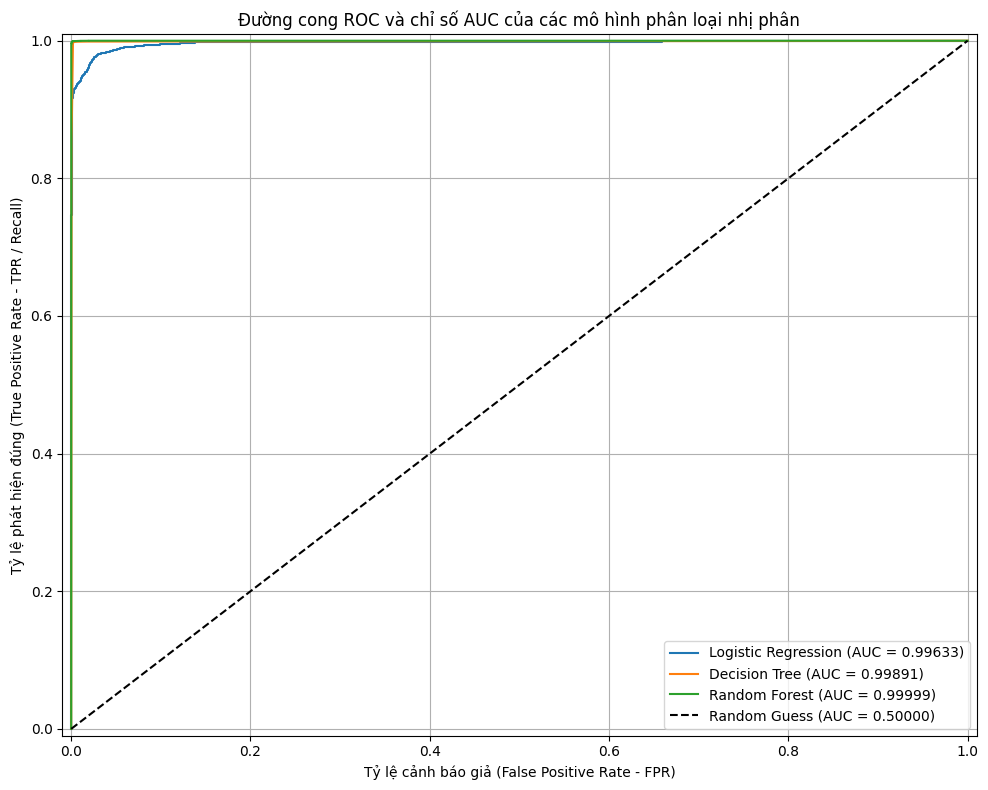

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

for name, (model, use_scaling) in models.items():
    X_te = X_test_scaled if use_scaling else X_test
    X_tr = X_train_scaled if use_scaling else X_train
    # Huấn luyện lại trên nhãn nhị phân để vẽ ROC/AUC chính xác
    model.fit(X_tr, y_train_bin)
    
    # Lấy xác suất dự đoán của lớp 1 (Attack)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    # Tính toán ROC curve và AUC score
    fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob)
    auc_score = roc_auc_score(y_test_bin, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.5f})")

# Vẽ đường phân định ngẫu nhiên
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50000)')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Tỷ lệ cảnh báo giả (False Positive Rate - FPR)')
plt.ylabel('Tỷ lệ phát hiện đúng (True Positive Rate - TPR / Recall)')
plt.title('Đường cong ROC và chỉ số AUC của các mô hình phân loại nhị phân')
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()